# COVID-19 Global Trends Analysis

## Objective
The objective of this project is to analyze COVID-19 trends over time using publicly available data. The analysis focuses on cases, deaths, and comparisons between countries to identify patterns and trends.

## Dataset Description

The dataset used in this project contains global COVID-19 statistics, including daily and cumulative cases and deaths. The data covers multiple countries and time periods, allowing trend analysis and country-level comparisons.

In [65]:
import pandas as pd

url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/jhu/full_data.csv"

df = pd.read_csv(url)

print(df.head())

         date     location  new_cases  new_deaths  total_cases  total_deaths  \
0  2020-02-24  Afghanistan        5.0         NaN          5.0           NaN   
1  2020-02-25  Afghanistan        0.0         NaN          5.0           NaN   
2  2020-02-26  Afghanistan        0.0         NaN          5.0           NaN   
3  2020-02-27  Afghanistan        0.0         NaN          5.0           NaN   
4  2020-02-28  Afghanistan        0.0         NaN          5.0           NaN   

   weekly_cases  weekly_deaths  biweekly_cases  biweekly_deaths  
0           NaN            NaN             NaN              NaN  
1           NaN            NaN             NaN              NaN  
2           NaN            NaN             NaN              NaN  
3           NaN            NaN             NaN              NaN  
4           NaN            NaN             NaN              NaN  


In [66]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(248346, 10)


In [67]:
print(df.columns)

Index(['date', 'location', 'new_cases', 'new_deaths', 'total_cases',
       'total_deaths', 'weekly_cases', 'weekly_deaths', 'biweekly_cases',
       'biweekly_deaths'],
      dtype='object')


In [68]:
df.isnull().sum()

,0
date,0
location,0
new_cases,271
new_deaths,19838
total_cases,9
total_deaths,19754
weekly_cases,1475
weekly_deaths,21024
biweekly_cases,3228
biweekly_deaths,22793


## Missing Value Analysis

The dataset contains some missing values (NaN). These missing values occur because certain countries did not report data for every metric on every date. Missing values are common in real-world datasets and were handled appropriately during the analysis.

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248346 entries, 0 to 248345
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             248346 non-null  object 
 1   location         248346 non-null  object 
 2   new_cases        248075 non-null  float64
 3   new_deaths       228508 non-null  float64
 4   total_cases      248337 non-null  float64
 5   total_deaths     228592 non-null  float64
 6   weekly_cases     246871 non-null  float64
 7   weekly_deaths    227322 non-null  float64
 8   biweekly_cases   245118 non-null  float64
 9   biweekly_deaths  225553 non-null  float64
dtypes: float64(8), object(2)
memory usage: 18.9+ MB


In [70]:
df['date'] = pd.to_datetime(df['date'])

print(df.dtypes)

date               datetime64[ns]
location                   object
new_cases                 float64
new_deaths                float64
total_cases               float64
total_deaths              float64
weekly_cases              float64
weekly_deaths             float64
biweekly_cases            float64
biweekly_deaths           float64
dtype: object


In [71]:
countries = ['Pakistan', 'India', 'United States']

selected = df[df['location'].isin(countries)]

selected.head()

,date,location,new_cases,new_deaths,total_cases,total_deaths,weekly_cases,weekly_deaths,biweekly_cases,biweekly_deaths
104095,2020-01-30,India,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN
104096,2020-01-31,India,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN
104097,2020-02-01,India,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN
104098,2020-02-02,India,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN
104099,2020-02-03,India,1.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN


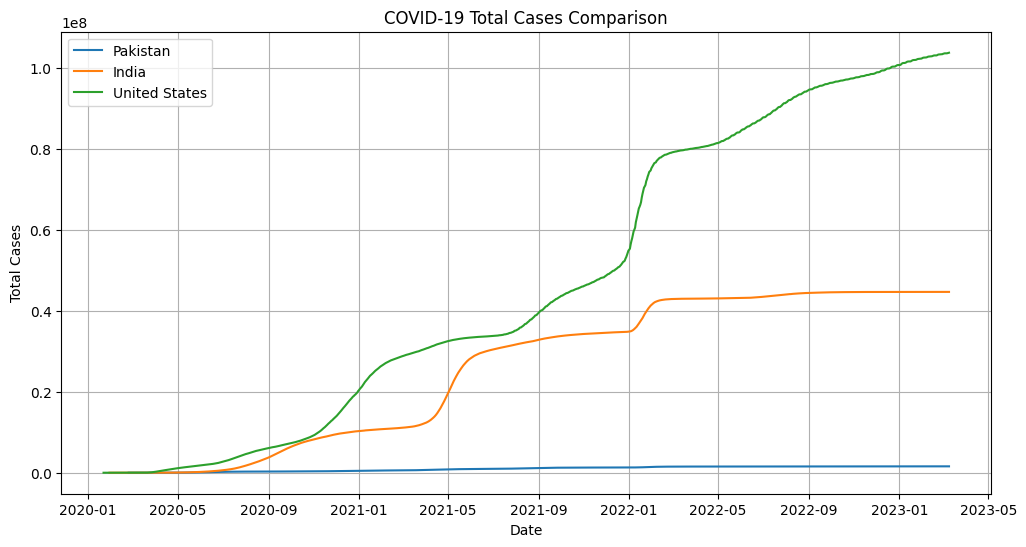

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for country in countries:
    data = selected[selected['location'] == country]
    plt.plot(data['date'], data['total_cases'], label=country)

plt.title('COVID-19 Total Cases Comparison')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.legend()
plt.grid(True)

plt.show()

## Total Cases Comparison

The graph compares cumulative COVID-19 cases across Pakistan, India, and the United States. The United States recorded the highest number of total cases, while Pakistan reported significantly fewer cases throughout the pandemic period.

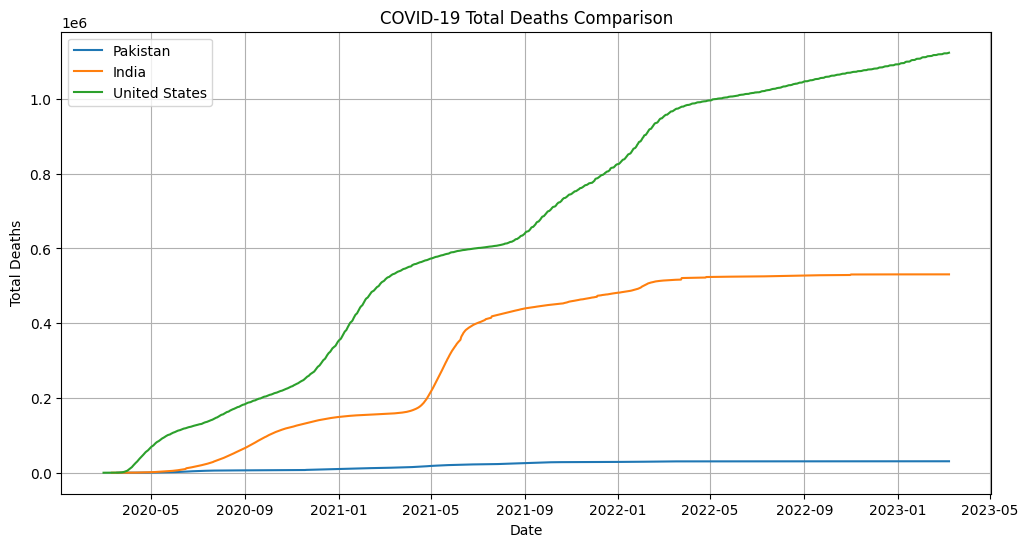

In [73]:
plt.figure(figsize=(12,6))

for country in countries:
    data = selected[selected['location'] == country]
    plt.plot(data['date'], data['total_deaths'], label=country)

plt.title('COVID-19 Total Deaths Comparison')
plt.xlabel('Date')
plt.ylabel('Total Deaths')
plt.legend()
plt.grid(True)

plt.show()

## Total Deaths Comparison

The death trends generally followed the growth of COVID-19 cases. Countries with larger outbreaks experienced higher cumulative death counts. The United States showed the highest mortality among the selected countries.

In [74]:
latest = df.sort_values('date').groupby('location').tail(1)

top10 = latest.sort_values(
    by='total_cases',
    ascending=False
).head(10)

top10[['location','total_cases']]

,location,total_cases
245109,World,676467356.0
99651,High income,431911049.0
75402,Europe,248452416.0
13233,Asia,210767366.0
76544,European Union,184184098.0
236730,Upper middle income,145057512.0
167302,North America,122717115.0
235587,United States,103802702.0
134531,Lower middle income,97175431.0
208245,South America,67963678.0


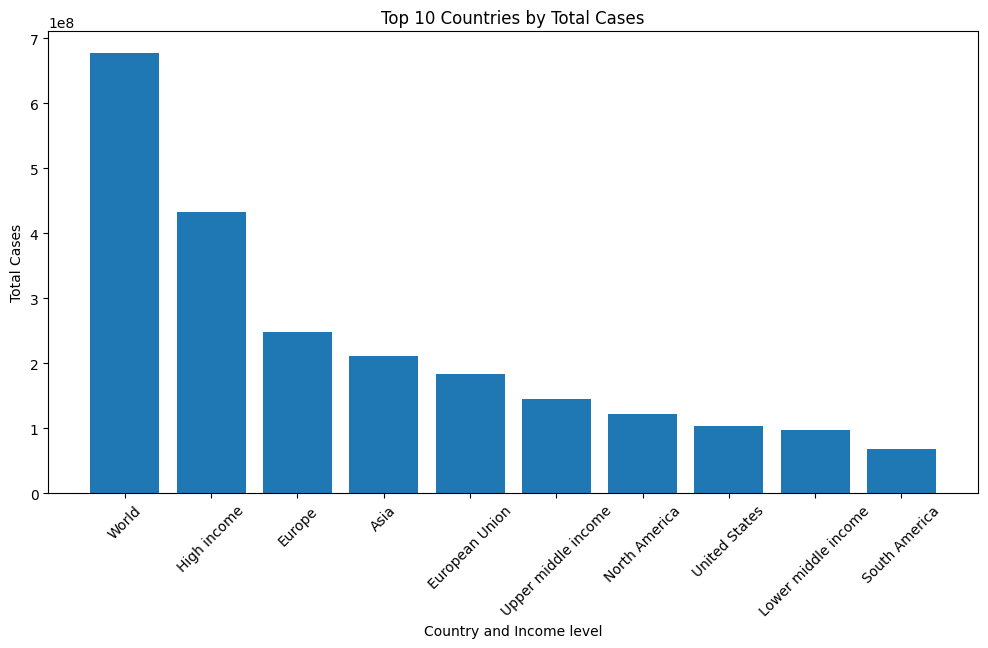

In [75]:
plt.figure(figsize=(12,6))

plt.bar(top10['location'], top10['total_cases'])

plt.title('Top 10 Countries by Total Cases')
plt.xlabel('Country and Income level')
plt.ylabel('Total Cases')

plt.xticks(rotation=45)

plt.show()

## Top Affected Countries

The chart highlights the countries with the largest cumulative COVID-19 case counts in countries and income levels across the world. These countries experienced substantial outbreaks and contributed significantly to global case totals.

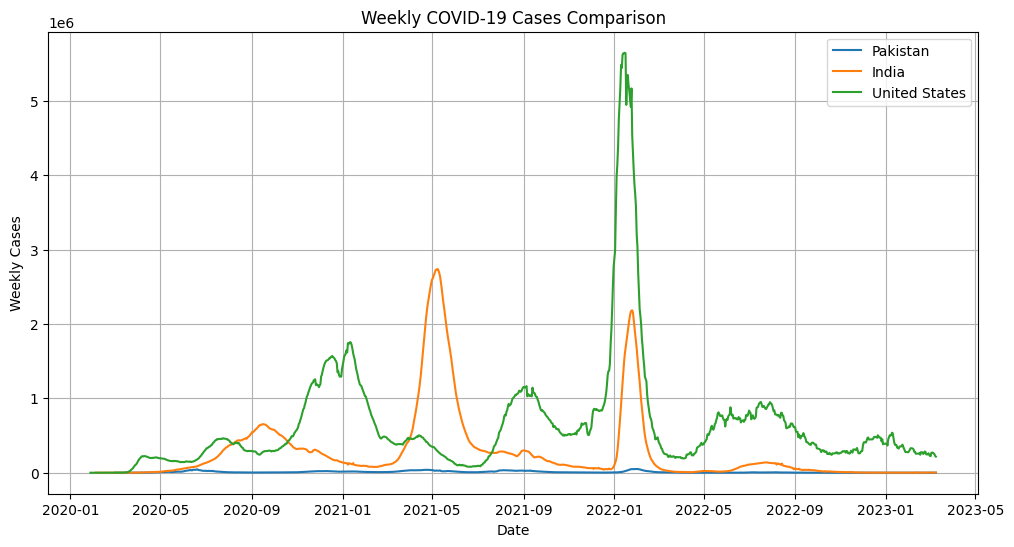

In [76]:
plt.figure(figsize=(12,6))

for country in countries:
    data = selected[selected['location'] == country]

    plt.plot(
        data['date'],
        data['weekly_cases'],
        label=country
    )

plt.title('Weekly COVID-19 Cases Comparison')
plt.xlabel('Date')
plt.ylabel('Weekly Cases')
plt.legend()
plt.grid(True)

plt.show()

## Weekly Cases Trend Analysis

The weekly cases graph highlights the progression of COVID-19 infections over time. Major waves of infection can be identified through sharp increases in weekly reported cases. The chart helps visualize periods of rapid spread and recovery.

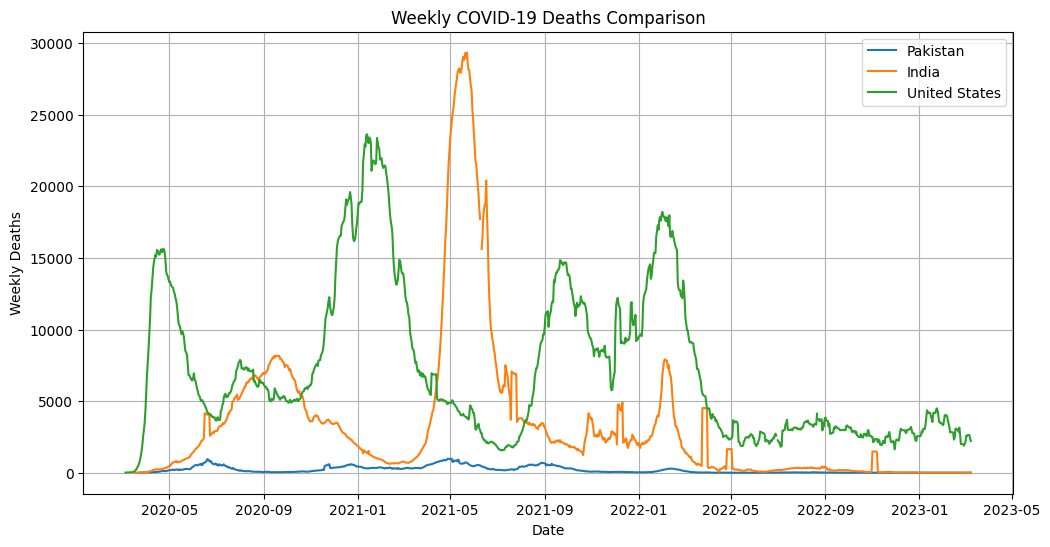

In [77]:
plt.figure(figsize=(12,6))

for country in countries:
    data = selected[selected['location'] == country]

    plt.plot(
        data['date'],
        data['weekly_deaths'],
        label=country
    )

plt.title('Weekly COVID-19 Deaths Comparison')
plt.xlabel('Date')
plt.ylabel('Weekly Deaths')
plt.legend()
plt.grid(True)

plt.show()

## Weekly Deaths Trend Analysis

The weekly deaths trend follows major COVID-19 outbreaks. Countries experiencing larger infection waves generally reported higher weekly death counts. The chart provides insight into the severity of the pandemic over time.

In [78]:
for country in countries:
    data = selected[selected['location'] == country]

    peak = data.loc[data['new_cases'].idxmax()]

    print("Country:", country)
    print("Peak Date:", peak['date'])
    print("Highest Daily Cases:", peak['new_cases'])
    print("----------------------")

Country: Pakistan
Peak Date: 2020-06-14 00:00:00
Highest Daily Cases: 12073.0
----------------------
Country: India
Peak Date: 2021-05-06 00:00:00
Highest Daily Cases: 414188.0
----------------------
Country: United States
Peak Date: 2022-01-10 00:00:00
Highest Daily Cases: 1354505.0
----------------------


## Peak Analysis Explanation

The peak analysis identifies the date on which each selected country reported its highest number of daily COVID-19 cases. These peaks represent major outbreak waves and help highlight periods when transmission was most intense. Comparing peak dates across countries provides insight into how the pandemic progressed differently in each region.

## Key Findings

- The United States recorded the highest cumulative COVID-19 cases among the selected countries.
- India experienced several major waves of infections during the pandemic.
- Pakistan reported comparatively lower total case counts.
- Weekly case trends revealed distinct peaks corresponding to outbreak periods.
- Death trends generally followed the rise and fall of confirmed cases.

## Conclusion

This project analyzed global COVID-19 trends using publicly available data. Comparisons among Pakistan, India, and the United States revealed significant differences in case and death counts. Time-series visualizations helped identify major waves, peaks, and anomalies throughout the pandemic. The findings demonstrate how data analytics can be used to monitor public health events and support informed decision-making.